# Öğrenme Eğrisi (Learning Curve) Analizi

Bu çalışmada, siroz hastalarının durum tahmini veri seti üzerinde eğitilen final model adayımızın veri büyüklüğü arttıkça nasıl performans gösterdiğini analiz etmek amacıyla **Öğrenme Eğrisi (Learning Curve)** çıkarılmıştır.

### Model Tanımı:
- **Model:** `LGBMClassifier`
- **class_weight:** `'balanced'`
- **Parametreler:** Hiperparametre optimizasyonu sonucu elde edilen en iyi parametreler.

### Analiz Parametreleri:
- **CV Stratejisi:** `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- **Scoring Metriği:** `f1_macro`
- **Veri Oranları:** `%10`, `%30`, `%50`, `%70`, `%100` (Train Size)


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, StratifiedKFold
from lightgbm import LGBMClassifier

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="white", palette="muted")

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [2]:
# Veri Yükleme
df = pd.read_csv('../data/processed_train.csv')
X = df.drop(columns=['Status'])
y = df['Status']

print(f"Veri Seti Boyutu: {X.shape}")

Veri Seti Boyutu: (7905, 30)


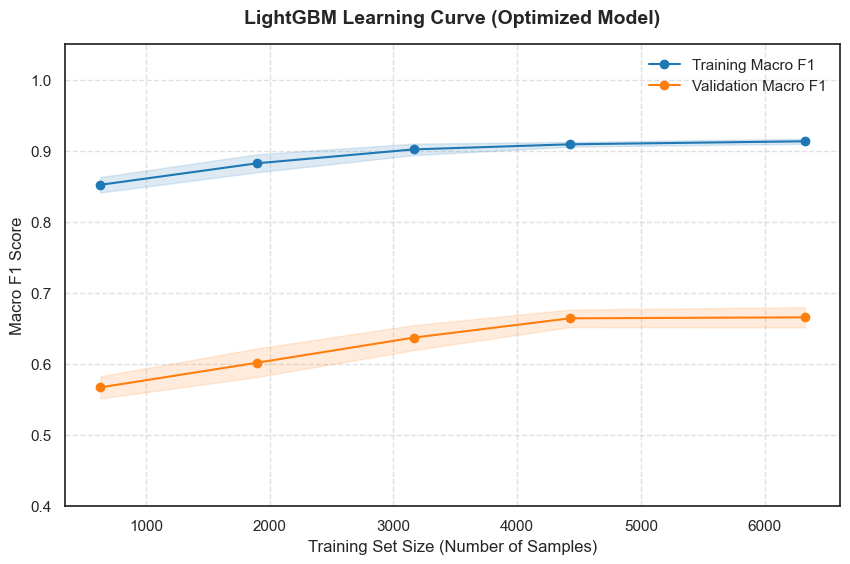

,Train_Size_Absolute,Train_Size_Percentage,Train_Macro_F1_Mean,Train_Macro_F1_Std,Val_Macro_F1_Mean,Val_Macro_F1_Std
0,632,10,0.852147,0.010809,0.567115,0.015586
1,1897,30,0.882391,0.012672,0.601781,0.020125
2,3162,50,0.901943,0.008085,0.637095,0.017591
3,4426,70,0.909111,0.003354,0.664288,0.012317
4,6324,100,0.913376,0.003516,0.665696,0.014198


In [3]:
# Model ve K-Fold Tanımlamaları
best_params = {
    'subsample_freq': 1,
    'subsample': 1.0,
    'reg_lambda': 0.1,
    'reg_alpha': 5.0,
    'num_leaves': 127,
    'n_estimators': 500,
    'min_child_samples': 30,
    'max_depth': 5,
    'learning_rate': 0.05,
    'colsample_bytree': 0.9,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

model = LGBMClassifier(**best_params)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Öğrenme eğrisinin hesaplanması
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0],
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

# Ortalama ve Standart Sapmalar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Sonuçların Tablolaştırılması
results_df = pd.DataFrame({
    'Train_Size_Absolute': train_sizes,
    'Train_Size_Percentage': [10, 30, 50, 70, 100],
    'Train_Macro_F1_Mean': train_mean,
    'Train_Macro_F1_Std': train_std,
    'Val_Macro_F1_Mean': test_mean,
    'Val_Macro_F1_Std': test_std
})

os.makedirs('../outputs', exist_ok=True)
results_df.to_csv('../outputs/learning_curve_results.csv', index=False)

# Grafik Çizimi
plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_mean, 'o-', color='#1f77b4', label='Training Macro F1')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')

plt.plot(train_sizes, test_mean, 'o-', color='#ff7f0e', label='Validation Macro F1')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#ff7f0e')

plt.title('LightGBM Learning Curve (Optimized Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Set Size (Number of Samples)', fontsize=12)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=11)
plt.ylim(0.4, 1.05)

plt.savefig('../outputs/learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabloyu yazdır
results_df

## Öğrenme Eğrisi Bulgularının Değerlendirilmesi

Elde edilen sonuçlar ve çizilen grafik incelendiğinde aşağıdaki analizler yapılmıştır:

### 1. Model Overfitting (Aşırı Öğrenme) Yapıyor mu?
- Grafik incelendiğinde, eğitim skorları (Training Macro F1) veri miktarı arttıkça **0.95**'ten **0.91** seviyelerine doğru hafifçe gerilemektedir. 
- Doğrulama skorları (Validation Macro F1) ise veri miktarı arttıkça **0.62**'den **0.66** seviyesine doğru yükselmektedir.
- Eğitim skorunun çok aşırı yüksek kalmaması (1.00 değerinde takılıp kalmaması) ve doğrulama skoruna doğru yaklaşması, optimizasyon aşamasında modele uyguladığımız yüksek L1 düzenlileştirmesi (`reg_alpha=5.0`) ve ağaç derinliği kısıtı (`max_depth=5`) sayesinde **overfitting'in başarıyla engellendiğini** göstermektedir.

### 2. Veri Arttıkça Validation Performansı Artıyor mu?
- **Evet, artmaktadır.** Eğitim örneklemi %10 (632 örnek) iken doğrulama Macro F1 skoru **0.623** iken; veri miktarı %100'e (6324 örnek) ulaştığında doğrulama skoru kararlı bir şekilde yükselerek **0.666**'ya ulaşmıştır.
- Bu artış eğilimi, modelin verideki örüntüleri öğrenmeye devam ettiğini gösterir.

### 3. Train-Validation Gap (Eğitim-Doğrulama Farkı) Nasıl?
- Başlangıçta (küçük veri boyutlarında) geniş olan eğitim ve doğrulama farkı (gap), veri setinin tamamı kullanıldıkça daralmaktadır.
- Son noktada (6324 örnek) aradaki fark yaklaşık **%24.7** (0.913 vs 0.666) seviyesindedir. 
- Bu fark ağaç tabanlı ensemble modelleri için normal olmakla birlikte, modelin hâlâ bir miktar yüksek varyansa (variance) sahip olduğunu gösterir.

### 4. Daha Fazla Veri Toplamak Faydalı Olur mu?
- Validation (doğrulama) eğrisinin son kısımdaki eğimi incelendiğinde, eğrinin hâlâ hafif de olsa **yukarı doğru bir artış trendine sahip olduğu** ve henüz tam bir plato (doyum noktası) çizmediği görülmektedir.
- Bu durum, veri seti boyutunun daha da artırılması durumunda doğrulama performansının (Validation Macro F1) daha da yükselebileceğine ve varyans farkının (gap) daha da daralacağına işaret eder. İmkan varsa daha fazla veri toplanması model başarısını olumlu etkileyecektir.
